In [133]:
import re
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("../data/kickstarter_preparation.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13345 entries, 0 to 13344
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   index                               13345 non-null  int64  
 1   id                                  13345 non-null  int64  
 2   name                                13345 non-null  object 
 3   blurb                               13344 non-null  object 
 4   goal                                13345 non-null  float64
 5   pledged                             13345 non-null  float64
 6   state                               13345 non-null  object 
 7   country                             13345 non-null  object 
 8   country_displayable_name            13345 non-null  object 
 9   currency                            13345 non-null  object 
 10  deadline                            13345 non-null  object 
 11  state_changed_at                    13345

In [6]:
df.columns

Index(['index', 'id', 'name', 'blurb', 'goal', 'pledged', 'state', 'country',
       'country_displayable_name', 'currency', 'deadline', 'state_changed_at',
       'created_at', 'launched_at', 'is_in_post_campaign_pledging_phase',
       'staff_pick', 'backers_count', 'static_usd_rate', 'usd_pledged',
       'spotlight', 'percent_funded', 'is_launched', 'prelaunch_activated',
       'creator_id', 'creator_name', 'category_id', 'category_name',
       'category_slug', 'category_parent_id', 'category_parent_name',
       'video_id', 'end', 'days', 'usd_pledged_per_day'],
      dtype='object')

In [ ]:
df["days_active"] = min(np.datetime64(df["deadline"]), np.datetime64("2026-04-02")) 

посмотрим, какие категории игр встречаются в датасете

In [7]:
df_games = df[df.category_slug.str.contains("game")]

In [17]:
games_categories = df_games.category_slug.value_counts()
games_categories, sum(games_categories)

(category_slug
 games/tabletop games     1128
 games/video games         407
 games/playing cards       153
 games/mobile games         27
 games/gaming hardware      19
 games/puzzles              17
 games/live games           16
 games                      13
 Name: count, dtype: int64,
 1780)

In [15]:
top_categories = games_categories.index[:4].values
top_categories

array(['games/tabletop games', 'games/video games', 'games/playing cards',
       'games/mobile games'], dtype=object)

лидеры - настольные игры, видеоигры, карточные игры, мобилки. Посчитаем, сколько в процентном отношении они зарабатывают от общих сборов а также сколько в среднем собирает один проект каждой категории

In [31]:
total_games_fundings = np.sum(df_games.pledged)
fundings_by_slug = df_games.groupby(by="category_slug").agg(
    total_fundings=pd.NamedAgg(column="pledged", aggfunc="sum"),
    avg_funding=pd.NamedAgg(column="pledged", aggfunc="mean"),
    avg_spotligth=pd.NamedAgg(column="spotlight", aggfunc="mean")
)
fundings_by_slug.total_fundings = 100 * fundings_by_slug.total_fundings / total_games_fundings
fundings_by_slug.total_fundings = np.round(fundings_by_slug.total_fundings, 3)

fundings_by_slug.avg_spotligth = 100 * fundings_by_slug.avg_spotligth 
fundings_by_slug.avg_spotligth = np.round(fundings_by_slug.avg_spotligth, 2)

fundings_by_slug.avg_funding = fundings_by_slug.avg_funding.astype(int)
fundings_by_slug = fundings_by_slug.sort_values(by="avg_funding", ascending=False)
fundings_by_slug

,total_fundings,avg_funding,avg_spotligth
category_slug,,,
games/gaming hardware,4.999,487311,31.58
games/video games,28.043,127615,23.34
games/playing cards,9.726,117732,23.53
games/tabletop games,56.716,93125,35.37
games,0.353,50277,23.08
games/puzzles,0.096,10473,41.18
games/live games,0.039,4552,12.50
games/mobile games,0.027,1865,0.00


Делаем вывод, что самые большие средние чеки находятся в категории `gaming hardware` а самое большие число проектов - `tabletop games`

Также заметим, что категории `games/puzzles`, `games/live games`, `games/mobile games` проигрывают как в числе заявок, так и в средних сборах. Гипотеза для проверки: эти категории глобально менее предпочтительны аудитории и имеют меньший чек.

Вторая гипотеза - средняя выручка от проектов с жанрами `games/video games`, `games/playing cards`, `games/tabletop games` примерно одинаковая

In [89]:
df_google_play = pd.read_csv("../data/google_play_games.csv")
df_google_play.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2837 entries, 0 to 2836
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2837 non-null   object
 1   name      2837 non-null   object
 2   rating    2837 non-null   object
 3   download  2829 non-null   object
 4   tags      2837 non-null   object
dtypes: object(5)
memory usage: 110.9+ KB


In [61]:
df_google_play.head()

,id,name,rating,download,tags
0,com.epicgames.fortnite,Fortnite,4.2star,10M+,"#5 top free action,Action,Shooter,Tactical sho..."
1,com.madfingergames.legends,Shadowgun Legends: Online FPS,4.3star,10M+,"Action,Shooter,Tactical shooter,Single player,..."
2,com.pixonic.wwr,War Robots Multiplayer Battles,4.5star,100M+,"Action,Shooter,Vehicle combat,Multiplayer,Comp..."
3,com.gamedevltd.modernstrike,Modern Strike Online: PvP FPS,4.5star,100M+,"Action,Shooter,Tactical shooter,Multiplayer,Co..."
4,com.imangi.templerun2,Temple Run 2: Endless Escape,4.1star,1B+,"Action,Platformer,Runner,Arcade,Single player,..."


займемся предобработкой: сначала столбей rating. в нем есть значения формата `4star` так и `4`, приведем тип данных к `float`  

In [ ]:
pattern = r'^(?P<first>\d)[,\.](?P<second>\d+).*'
repl = r'\g<first>.\g<second>'


def normalize_rating(s):
    if re.match(pattern, s):
        res = re.sub(pattern, repl, s)
        return np.round(np.float32(res), 2)
    return np.nan


df_google_play["rating"] = df_google_play["rating"].apply(normalize_rating)

In [88]:
df_google_play["rating"].describe()

count    2829.000000
mean        4.222906
std         0.474303
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: rating, dtype: float64

посмотрим топ тегов по скачиваниям и рейтингу

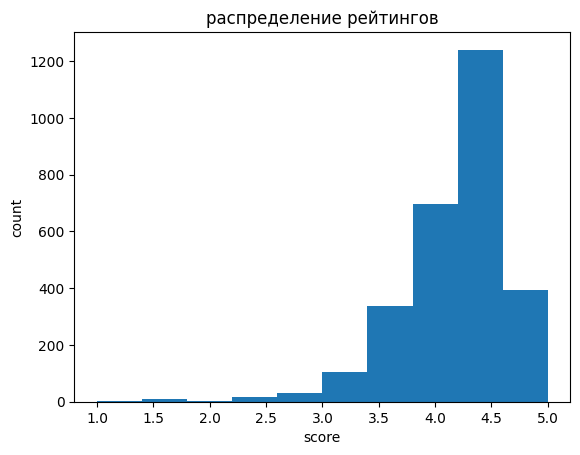

In [94]:
plt.hist(df_google_play.rating)
plt.title("распределение рейтингов")
plt.xlabel("score")
plt.ylabel("count")
plt.show()

красота!!

tags
Stylized         1950
Single player    1842
Offline          1125
Casual           1107
Multiplayer       731
Name: count, dtype: int64


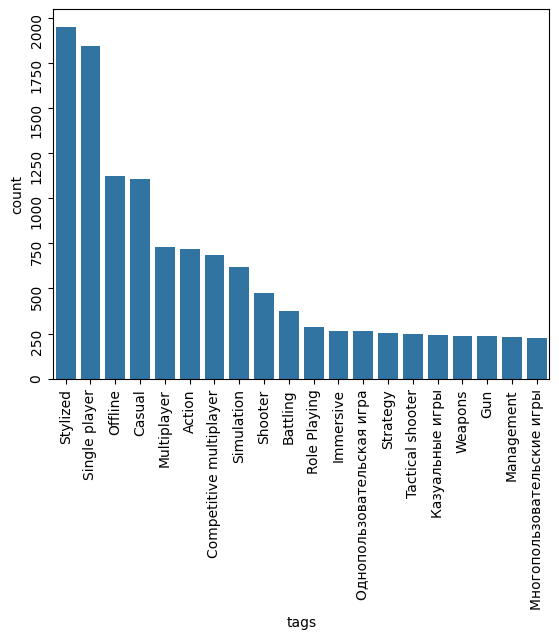

In [ ]:
tags = df_google_play.tags.str.split(",").explode()
tags_dist = tags.value_counts()
tags_top = tags_dist.iloc[:20]
print(tags_top.head())
sns.barplot(data=tags_top)
plt.tick_params(rotation=90)
plt.show()


нашей целью было проверить, являются ли категории `games/puzzles`, `games/live games`, `games/mobile games` менее популярными и востребованными

найдем эти теги

In [119]:
tags_puzzles_i = (tags_dist.index.str.contains("puz")) | (tags_dist.index.str.contains("пазл"))
tags_puzzles = tags_dist.index[tags_puzzles_i]
tags_puzzles

Index(['#3 top free puzzle', '#8 top free puzzle', '#7 top free puzzle',
       'Physics-puzzle RPG'],
      dtype='object', name='tags')

In [120]:
tags_live_games_i = (tags_dist.index.str.contains("live"))
tags_live_games = tags_dist.index[tags_live_games_i]
tags_live_games

Index([], dtype='object', name='tags')

такой категории у нас к сожалению нет.

In [121]:
tags_mobile_i = (tags_dist.index.str.contains("mobile"))
tags_mobile = tags_dist.index[tags_mobile_i]
tags_mobile

Index([], dtype='object', name='tags')

все игры в google play мобильные...

In [ ]:
games_puzzles_i = df_google_play.tags.apply(lambda x: any([tag in tags_puzzles.values for tag in x.split(",")]))
puzzle_games = df_google_play[games_puzzles_i]
puzzle_games


,id,name,rating,download,tags
335,com.block.juggle,Block Blast!,4.7,500M+,"#3 top free puzzle,Puzzle,Block,Casual,Single ..."
345,com.oakever.tiletrip,Tile Explorer - Triple Match,4.8,100M+,"#7 top free puzzle,Puzzle,Match 3,Casual,Singl..."
630,com.block.juggle,Block Blast!,4.7,500M+,"#3 top free puzzle,Puzzle,Block,Casual,Single ..."
679,com.onebutton.mrsuper2,The Superhero League 2,4.5,10M+,"#8 top free puzzle,Puzzle,Physics,Casual,Singl..."
1325,com.nkm.kp.hh,Hyper Heroes: Marble-Like RPG,3.5,10M+,"Role Playing,Puzzle Role-playing,Physics-puzzl..."


In [124]:
avg_puzzle_rating = puzzle_games.rating.mean()

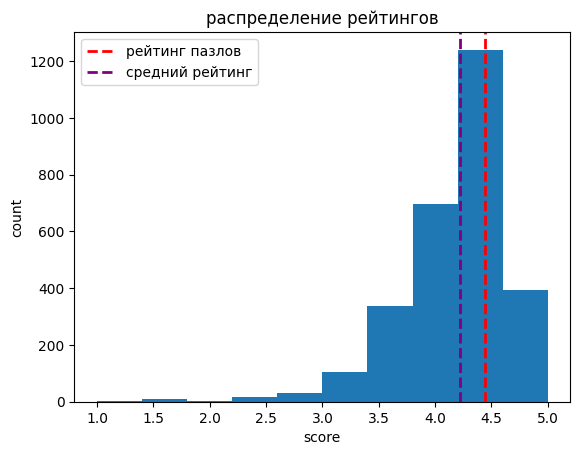

In [126]:
plt.hist(df_google_play.rating)
plt.axvline(avg_puzzle_rating, color='red', linestyle='--', linewidth=2, label="рейтинг пазлов")
plt.axvline(df_google_play.rating.mean(), color='purple', linestyle='--', linewidth=2, label="средний рейтинг")
plt.title("распределение рейтингов")
plt.xlabel("score")
plt.ylabel("count")
plt.legend() 
plt.show()

Проверим карточные игры

In [127]:
tags_cards_i = (tags_dist.index.str.contains("card")) | (tags_dist.index.str.contains("карт"))
tags_cards = tags_dist.index[tags_cards_i]
tags_cards

Index(['Сброс карт', 'Classic cards', 'Классическая карточная игра'], dtype='object', name='tags')

In [128]:
games_cards_i = df_google_play.tags.apply(lambda x: any([tag in tags_cards.values for tag in x.split(",")]))
card_games = df_google_play[games_puzzles_i]
card_games

,id,name,rating,download,tags
335,com.block.juggle,Block Blast!,4.7,500M+,"#3 top free puzzle,Puzzle,Block,Casual,Single ..."
345,com.oakever.tiletrip,Tile Explorer - Triple Match,4.8,100M+,"#7 top free puzzle,Puzzle,Match 3,Casual,Singl..."
630,com.block.juggle,Block Blast!,4.7,500M+,"#3 top free puzzle,Puzzle,Block,Casual,Single ..."
679,com.onebutton.mrsuper2,The Superhero League 2,4.5,10M+,"#8 top free puzzle,Puzzle,Physics,Casual,Singl..."
1325,com.nkm.kp.hh,Hyper Heroes: Marble-Like RPG,3.5,10M+,"Role Playing,Puzzle Role-playing,Physics-puzzl..."


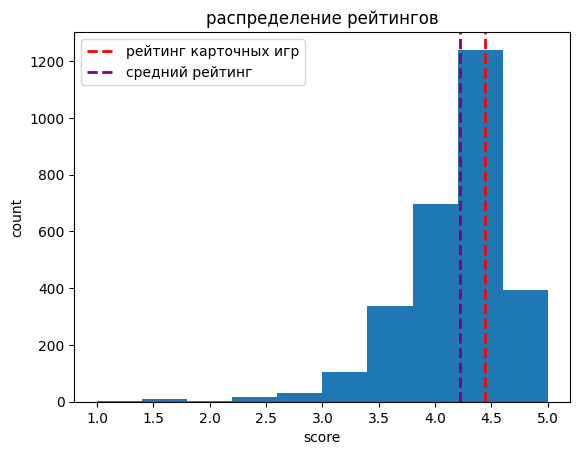

In [161]:
plt.hist(df_google_play.rating)
plt.axvline(card_games.rating.mean(), color='red', linestyle='--', linewidth=2, label="рейтинг карточных игр")
plt.axvline(df_google_play.rating.mean(), color='purple', linestyle='--', linewidth=2, label="средний рейтинг")
plt.title("распределение рейтингов")
plt.xlabel("score")
plt.ylabel("count")
plt.legend() 
plt.show()

делаем вывод, что несмотря на данные кикстартера, у категорий карты и пазлы есть небольшие преимущества 

In [145]:
df_steam = pd.read_csv("../data/steam_games.csv")
df_steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2441 entries, 0 to 2440
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   type                 2441 non-null   object
 1   name                 2441 non-null   object
 2   is_free              2441 non-null   bool  
 3   short_description    2441 non-null   object
 4   supported_languages  2410 non-null   object
 5   header_image         2440 non-null   object
 6   price_overview       1865 non-null   object
 7   recommendations      1357 non-null   object
 8   categories           2414 non-null   object
 9   genres               2410 non-null   object
 10  release_date         2441 non-null   object
 11  ratings              2346 non-null   object
dtypes: bool(1), object(11)
memory usage: 212.3+ KB


In [146]:
df_steam.head()

,type,name,is_free,short_description,supported_languages,header_image,price_overview,recommendations,categories,genres,release_date,ratings
0,game,DEATH STRANDING 2: ON THE BEACH,False,Sam – with companions by his side – sets out o...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,"{'currency': 'USD', 'initial': 6999, 'final': ...",{'total': 9134},"[{'id': 2, 'description': 'Single-player'}, {'...","[{'id': '1', 'description': 'Action'}, {'id': ...","{'coming_soon': False, 'date': 'Mar 19, 2026'}","{'pegi': {'rating': '18', 'descriptors': 'Viol..."
1,game,THE KING OF FIGHTERS XV,False,SHATTER ALL EXPECTATIONS! Transcend beyond you...,"English, Japanese<strong>*</strong>, French, I...",https://shared.akamai.steamstatic.com/store_it...,"{'currency': 'USD', 'initial': 1499, 'final': ...",{'total': 8063},"[{'id': 2, 'description': 'Single-player'}, {'...","[{'id': '1', 'description': 'Action'}]","{'coming_soon': False, 'date': '12 Dec, 2024'}","{'dejus': {'rating': '12', 'descriptors': 'Con..."
2,game,Ratchet & Clank: Rift Apart,False,Blast your way through an interdimensional adv...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,"{'currency': 'EUR', 'initial': 5999, 'final': ...",{'total': 10842},"[{'id': 2, 'description': 'Single-player'}, {'...","[{'id': '1', 'description': 'Action'}, {'id': ...","{'coming_soon': False, 'date': '26 Jul, 2023'}","{'esrb': {'rating': 'e10', 'descriptors': 'Ani..."
3,dlc,"DSX+ (Virtual DualSense, BT Audio/Haptics) DLC",False,Extend your control even further with the DSX+...,"English, French, Italian, German, Arabic, Bulg...",https://shared.akamai.steamstatic.com/store_it...,"{'currency': 'EUR', 'initial': 519, 'final': 5...",{'total': 580},"[{'id': 2, 'description': 'Single-player'}, {'...","[{'id': '57', 'description': 'Utilities'}]","{'coming_soon': False, 'date': '27 Oct, 2023'}","{'dejus': {'rating_generated': '1', 'rating': ..."
4,game,"Gremlins, Inc.",False,This is an intense strategy board game in a st...,"English, French, German, Spanish - Spain, Russ...",https://shared.akamai.steamstatic.com/store_it...,"{'currency': 'EUR', 'initial': 1999, 'final': ...",{'total': 6592},"[{'id': 2, 'description': 'Single-player'}, {'...","[{'id': '23', 'description': 'Indie'}, {'id': ...","{'coming_soon': False, 'date': '10 Mar, 2016'}","{'dejus': {'rating': '12', 'descriptors': 'Ato..."


сделаем признак `recommendations` не вложенным

In [147]:
def rec_to_num(s):
    if pd.isna(s): return np.nan
    return ast.literal_eval(s).get('total', np.nan)


df_steam.recommendations = df_steam.recommendations.apply(rec_to_num)
df_steam.recommendations.head()

0     9134.0
1     8063.0
2    10842.0
3      580.0
4     6592.0
Name: recommendations, dtype: float64

также разложим жарны из вложенной структуры в строку с жанрами через запятую.

In [157]:
def genre_to_str(s):
    if pd.isna(s): return np.nan
    game_genres_records = ast.literal_eval(s)
    desc = [d['description'] for d in game_genres_records if 'description' in d]
    return ','.join(desc)

df_steam.genres = df_steam.genres.apply(genre_to_str)
df_steam.genres.head()

0    Action,Adventure
1              Action
2    Action,Adventure
3           Utilities
4      Indie,Strategy
Name: genres, dtype: object

проверим распределения игр по жанрам

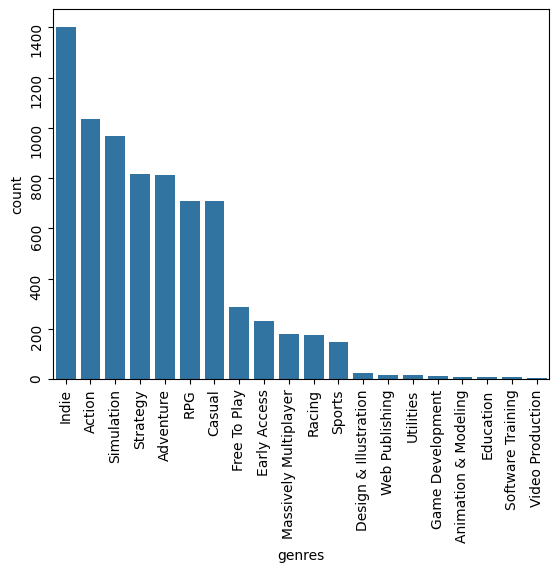

In [158]:
genres = df_steam.genres.str.split(",").explode()
genres_dist = genres.value_counts()
genres_top = genres_dist.iloc[:20]
sns.barplot(data=genres_top)
plt.tick_params(rotation=90)
plt.show()

интересующие нас жанры: `playing cards`, `puzzles`, `live games`, `tabletop games`

In [159]:
steam_cards_genres_i = (genres_dist.index.str.contains("card")) | (genres_dist.index.str.contains("карт"))
steam_cards_genres = genres_dist.index[steam_cards_genres_i]
steam_cards_genres

Index([], dtype='object', name='genres')

In [160]:
steam_puzzles_i = (genres_dist.index.str.contains("puz")) | (genres_dist.index.str.contains("пазл"))
steam_puzzles_genres = genres_dist.index[steam_puzzles_i]
steam_puzzles_genres

Index([], dtype='object', name='genres')

видим, что в датасете нет данных, которые попадают в наши категории и для анализа его использовать не получится.

**Финальные рекомендации по категориям:**

- `games/gaming hardware` нет данных, оставляем как есть +0%
- `games/video games` популярный сектор, в котором есть разнообразие жарнров, много игроков, +10%
- `games/playing cards`	на данных google play показал себя лучше стреднего по отзывам, но малая выборка +5%
- `games/tabletop games` не нашли подстверждающих данных, +0%
- `games` - не меняем от базового, +0%
- `games/puzzles` - показал себя с большими рейтингами, но малая выборка +5%	
- `games/live games` - не нашли в данных, +0%
- `games/mobile games` - большой объем рынка, но очень неразвит на kickstarter (мало проектов), +3%